In [26]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np

# IOB Fits


Reading from configuration file: conf/iob_1.ini

Target: A

All model lengths:
[  5   6   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21  22
  23  24  25  26  27  28  29  30  31  32  33  34  36  37  38  39  40  41
  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59
  60  61  62  63  64  65  66  67  68  69  70  71  72  73  75  77  79  81
  82  83  85  87  89  95  96  97  98  99 100 101 102 103 104]

Equation requested:
((-0.000187) + (1.000119 * (((((1.164343 * X9) ^ 2) ^ ((0.580242 * X9) ^ ((15.999866 * X1) + 2.203717))) + (1.099369 * X3)) * (((1.512951 * X9) ^ ((-21.478468) * X9)) * ((((1.557161 * X9) ^ (19.669573 * X9)) - ((((-0.667822) * X3) + 0.005825) - (((2.876986 * X9) ^ ((1.793367 * X9) ^ ((-17.183067) * X9))) * ((((-0.272574) * X4) + (0.055376 * X1)) + ((0.253206 * X3) + 0.005807))))) - ((((3.077280 * X9) ^ (((-10.454306) * X3) + (9.305380 * X9))) * (0.210492 * X2)) + (((((244.133896 * X3) + ((-55.554996) * X2)) + (((-109.817665) * X1) + (-12.5

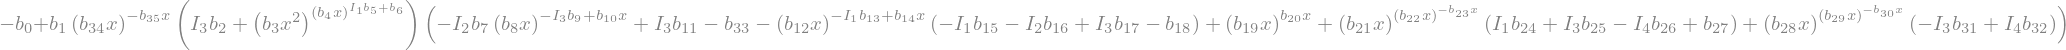


Latex version:
- b_{0} + b_{1} \left(b_{34} x\right)^{- b_{35} x} \left(I_{3} b_{2} + \left(b_{3} x^{2}\right)^{\left(b_{4} x\right)^{I_{1} b_{5} + b_{6}}}\right) \left(- I_{2} b_{7} \left(b_{8} x\right)^{- I_{3} b_{9} + b_{10} x} + I_{3} b_{11} - b_{33} - \left(b_{12} x\right)^{- I_{1} b_{13} + b_{14} x} \left(- I_{1} b_{15} - I_{2} b_{16} + I_{3} b_{17} - b_{18}\right) + \left(b_{19} x\right)^{b_{20} x} + \left(b_{21} x\right)^{\left(b_{22} x\right)^{- b_{23} x}} \left(I_{1} b_{24} + I_{3} b_{25} - I_{4} b_{26} + b_{27}\right) + \left(b_{28} x\right)^{\left(b_{29} x\right)^{- b_{30} x}} \left(- I_{3} b_{31} + I_{4} b_{32}\right)\right)
-b0 + b1*(b2*IOB3 + (b3*lam**2)**((b4*lam)**(b5*IOB1 + b6)))*(-b7*IOB2*(b8*lam)**(-b9*IOB3 + b10*lam) + b11*IOB3 - (b12*lam)**(-b13*IOB1 + b14*lam)*(-b15*IOB1 - b16*IOB2 + b17*IOB3 - b18) + (b19*lam)**(b20*lam) + (b21*lam)**((b22*lam)**(-b23*lam))*(b24*IOB1 + b25*IOB3 - b26*IOB4 + b27) + (b28*lam)**((b29*lam)**(-b30*lam))*(-b31*IOB3 + b32*IOB4) - b33)

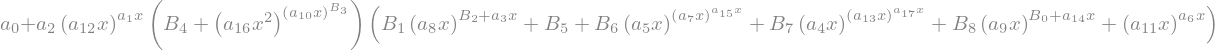

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------



(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Fit to A'}, xlabel='Model Length', ylabel='Root Mean Squared Error'>)

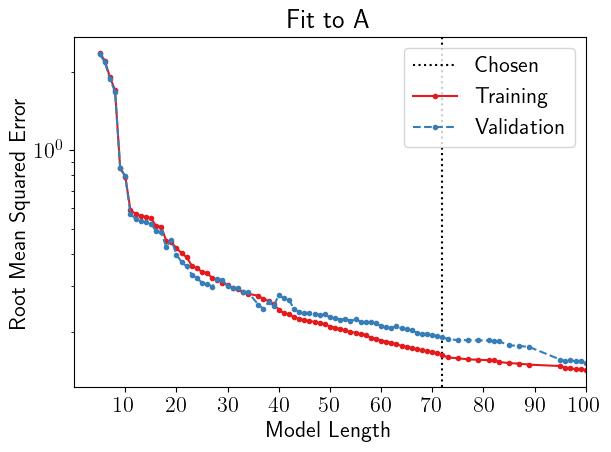

In [29]:
ini_file = 'conf/iob_1.ini'; ilen = None
ilen = 72
processing_fun.plot_pareto(ini_file, ilen=ilen)
# processing_fun.prediction_plots(ini_file, ilen=ilen);
# processing_fun.plot_example(ini_file, ilen=ilen, nexamples=6);

# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


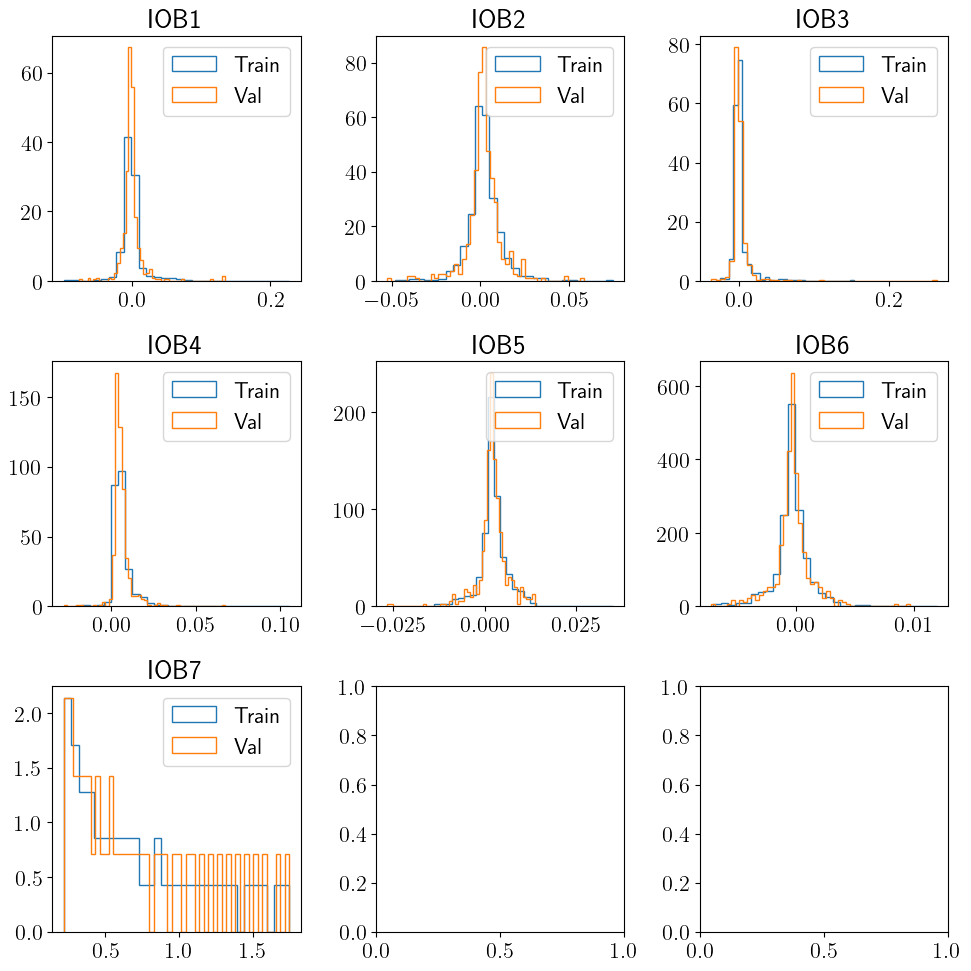

In [6]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()